# Convergência e Lei dos Grandes Números  

## Considere a estimativa da integral:

### I = ∫ [0, 1] ln( 1 + x) dx 

(a) Estime I usando Monte Carlo com amostragem uniforme.  
(b) Execute simulações com N = 10², 10³, 10⁴, 10⁵.  
(c) Plote o erro absoluto em função de N.  

<a href="https://colab.research.google.com/github/jgocana/Trabalhos-TP-547/blob/master/Trabalho%202/convergencia_e_lei_dos_grandes_numeros.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [ ]:
!pip install numpy
!pip install math
!pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement math (from versions: none)
ERROR: No matching distribution found for math


Note: you may need to restart the kernel to use updated packages.



=== QUESTÃO 1 ===

=== a) ===
Valor exato: I = 0.386294361119891

=== b) ===
N=    100 | I_hat=0.3683034096 | erro_abs=0.0179909515
N=   1000 | I_hat=0.3764629529 | erro_abs=0.0098314082
N=  10000 | I_hat=0.3874363205 | erro_abs=0.0011419594
N= 100000 | I_hat=0.3867429542 | erro_abs=0.0004485931

=== c) ===


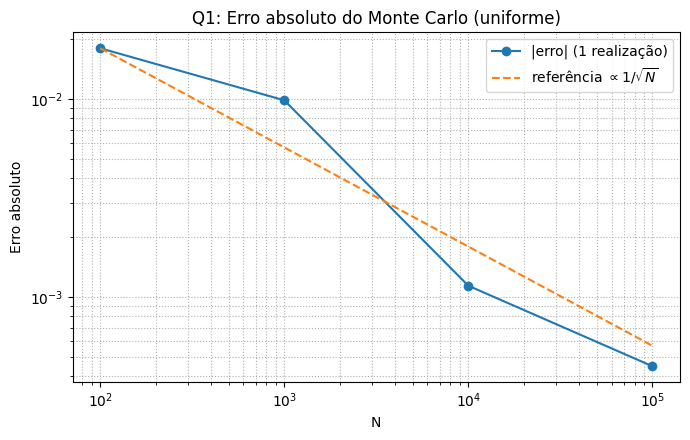

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ============================================================
# QUESTÃO 1 — Monte Carlo uniforme para I = ∫_0^1 ln(1+x) dx
# ============================================================

def questao1_mc_uniforme(seed=20260406):
    """
    (a) Estima I via Monte Carlo com amostragem uniforme.
    (b) Executa para N = 1e2, 1e3, 1e4, 1e5.
    (c) Plota erro absoluto em função de N.
    """

    # ---- Valor exato (para calcular erro):
    # ∫ ln(1+x) dx = (1+x)ln(1+x) - (1+x) + C
    # I = [ (1+x)ln(1+x) - (1+x) ]_0^1 = 2 ln2 - 1
    I_exato = 2 * math.log(2) - 1

    # Tamanhos pedidos
    Ns = np.array([10**2, 10**3, 10**4, 10**5])
    Nmax = Ns.max()

    # Gerador aleatório com semente (reprodutível)
    rng = np.random.default_rng(seed)

    # Gera Nmax amostras Uniforme(0,1)
    U = rng.random(Nmax)

    # Função integranda avaliada nas amostras
    f = np.log(1 + U)

    # Soma acumulada para reaproveitar prefixos (eficiente)
    soma_acum = np.cumsum(f)

    # Estimativas para cada N: média dos primeiros N valores
    I_hat = soma_acum[Ns - 1] / Ns

    # Erro absoluto
    erro_abs = np.abs(I_hat - I_exato)

    # ---- Imprime resultados
    print("\n=== QUESTÃO 1 ===")
    print("\n=== a) ===")
    print(f"Valor exato: I = {I_exato:.15f}")
    
    print("\n=== b) ===")
    for N, est, err in zip(Ns, I_hat, erro_abs):
        print(f"N={N:>7d} | I_hat={est:.10f} | erro_abs={err:.10f}")

# ============================================================
# 3) Plot error absoluto vs N
#    (en escala log-log es más fácil ver la tasa ~ 1/sqrt(N))
# ============================================================

    print("\n=== c) ===")
    plt.figure(figsize=(7, 4.5))
    plt.loglog(Ns, erro_abs, marker="o", label="|erro| (1 realização)")

    # Linha de referência ~ 1/sqrt(N) para comparar tendência MC)
    c_ref = erro_abs[0] * math.sqrt(Ns[0])
    ref = c_ref / np.sqrt(Ns)
    plt.loglog(Ns, ref, "--", label=r"referência $\propto 1/\sqrt{N}$")

    plt.xlabel("N")
    plt.ylabel("Erro absoluto")
    plt.title("Q1: Erro absoluto do Monte Carlo (uniforme)")
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Executa
if __name__ == "__main__":
    questao1_mc_uniforme()